# Evaluating/ validating Pathfinder + UWiBaSS snow depths against MP

In [19]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath('../Pathfinder'))

from helper_functions import *
from radar_functions import *
from pathfinder import *
from attach_grounddata import *
from add_dataflashlog import *
from clicki_tool import *

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
campaigns = [
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'SIOS2022',
    'CIRFA2022',
    '2024_ESASnowDrone',
    '2024_ESASnowDrone',
    '2024_ESASnowDrone',
    '2025_St3TARTFO',
    ]

targets = [
    'land',
    'land',
    'land',
    'land',
    'land',
    'land',
    'land',
    'land',
    'land',
    'land',
    'land',
    'land',
    'land',
    'land',
    'sea ice',
    'land',
    'sea ice',
    'sea ice',
    'sea ice'
]

sets = [
    '29_03_2022_4',
    '29_03_2022_9',
    '30_03_2022_1',
    '30_03_2022_2',
    '30_03_2022_3',
    '30_03_2022_4',
    '30_03_2022_6',
    '30_03_2022_9',
    '31_03_2022_2',
    '31_03_2022_10',
    '31_03_2022_11',
    '01_04_2022_1',
    '01_04_2022_2',
    '01_04_2022_5',
    '28_04_2022_1',
    '26_04_2024_3',
    '30_04_2024_1', 
    '01_05_2024_2',
    '24_04_2025_3'
    ]   #,'01_04_2022_10', 31_03_2022_3



colors_list = ['#2f4f4f',
               '#a52a2a',
               '#006400',
               '#000080',
               '#ff8c00',
               '#ffff00',
               '#00ff00',
               '#00bfff',
               '#0000ff',
               '#ff00ff',
               '#dda0dd',
               '#ff1493',
               '#98fb98',
               '#ffdead',
               "#78a7b1",
               'grey',
               "#3f062e",
               "#5f3900",
               "#9541bf"
               ]  #, '#dcdcdc']



In [81]:
R2s = []
RMSEs = []
MAEs = []


# fig, ax = plt.subplots(1,1, figsize=(7, 7), sharex=True, sharey=True, constrained_layout=True)
xvar = []
yvar = []
yerr = []
maskis = []
sea_ice_maskis = []
colorsi = []
colorsi2 = []
markersi = []
count_under_penetration_all = 0
count_under_penetration_true = 0

for k, (target, datasetID, campaignID) in enumerate(zip(targets, sets, campaigns)):
    # full_path = os.path.join(dir if dataset!='24_04_2025_3' else'/Users/torka/NORCE_T/St3TART-FO/Uwibass' , dataset, 'uwibass_object.pkl')

    # with open(full_path, 'rb') as inp:
    #     uwibass = pickle.load(inp)
    
    RADAR = load_RADAR(radar_type='UWiBaSS',
                    datasetID=datasetID,
                    campaignID=campaignID,
                    yaml_file="./campaigns.yaml"
                    )
        
    # uwibass.CTUN_SAlt_filtered = remove_altitude_outliers(uwibass.CTUN_SAlt, diff_threshold=1)
    # uwibass.expected_snow_depth = 1.5 if uwibass.is_sea_ice == False else 0.5
    # uwibass.altitude_mask = (uwibass.CTUN_SAlt_filtered < 2 * (uwibass.range_air[-1] / 100) - 2 * uwibass.expected_snow_depth) & (uwibass.CTUN_SAlt_filtered > 1 * (uwibass.range_air[-1] / 100) + uwibass.expected_snow_depth)
    
    
    unique_MP_indices = np.unique([item for sublist in RADAR.MP_indices[RADAR.altitude_mask] for item in sublist])
    internals = RADAR.PF_internal_layers['paths']

    MP_depths = []
    UWB_depths = []
    UWB_uncertainties = []
    colors = []
    marker = []
    colors2 = []
    maski = []
    sea_ice_maski = []
    j = 0
    
    for ind in unique_MP_indices:
        colors.append('grey')
        marker.append('o' if target=='land' else '^')
        colors2.append(colors_list[k])
        maski.append(True)
        sea_ice_maski.append(True if target=='sea ice' else False)
        indices = [i for i, item in enumerate(RADAR.MP_indices) if ind in item]
        
        ind_UWB_depths = np.array([RADAR.PF_snow_depth[i] for i, item in enumerate(RADAR.MP_indices) if ind in item])
        ind_UWB_uncs = np.array([RADAR.PF_snow_depth_uncertainty[i] for i, item in enumerate(RADAR.MP_indices) if ind in item])
                    
        ind_MP_depth = np.nanmedian([RADAR.MP_snow_depth[i] for i, item in enumerate(RADAR.MP_indices) if ind in item])
        ind_MP_index = np.nanmedian([RADAR.MP_snow_depth_in_indices[i] for i, item in enumerate(RADAR.MP_indices) if ind in item])

        if np.all(ind_MP_depth/100 < ind_UWB_depths - RADAR.range_resolution_snow/4):
            count_under_penetration_all += 1
            
            for path in internals:
                py, px = list(zip(*path))
                py = np.array(py)
                py_extended = np.unique(np.concatenate([py, py-2, py - 1, py + 1, py + 2]))
                px = np.array(px)
                
                if any(i in px for i in indices):
                    
                    if ind_MP_index in py_extended:
                        colors[j] = 'firebrick'
                        count_under_penetration_true += 1
                        maski[j] = False

        
        UWB_depths.append(ind_UWB_depths[np.argmin(np.abs(ind_UWB_depths - ind_MP_depth/100))])
        MP_depths.append(ind_MP_depth/100)

        UWB_uncertainties.append(ind_UWB_uncs[np.argmin(np.abs(ind_UWB_depths - ind_MP_depth/100))])
        j += 1

    R2s.append(np.corrcoef(np.array(MP_depths)[maski], np.array(UWB_depths)[maski])[0, 1])
    RMSEs.append(np.sqrt(np.mean((np.array(MP_depths)[maski] - np.array(UWB_depths)[maski])**2)))
    MAEs.append(np.mean(np.abs(np.array(MP_depths)[maski] - np.array(UWB_depths)[maski])))

        

    xvar.append(np.array(MP_depths))
    yvar.append(np.array(UWB_depths))
    yerr.append(np.array(UWB_uncertainties))
    maskis.append(np.array(maski))
    colorsi.append(np.array(colors))
    markersi.append(np.array(marker))
    sea_ice_maskis.append(np.array(sea_ice_maski))
    colorsi2.append(np.array(colors2))
    # plot_MP_validation(uwibass, ax=ax, mode='snow_depth_best')
    
    del RADAR
    
xvars = np.concatenate(xvar)
yvars = np.concatenate(yvar)
yerrs = np.concatenate(yerr)
maskiss = np.concatenate(maskis)
colorsis = np.concatenate(colorsi)
colorsi2s = np.concatenate(colorsi2)
markersis = np.concatenate(markersi)
sea_ice_maskiss = np.concatenate(sea_ice_maskis)
RADAR = load_RADAR(radar_type='UWiBaSS',
                    datasetID=datasetID,
                    campaignID=campaignID,
                    yaml_file="./campaigns.yaml"
                    )
        

Dataset 29_03_2022_4 from campaign SIOS2022 is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/29_03_2022_4/uwibass_object.pkl
Dataset 29_03_2022_9 from campaign SIOS2022 is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/29_03_2022_9/uwibass_object.pkl
Dataset 30_03_2022_1 from campaign SIOS2022 is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/30_03_2022_1/uwibass_object.pkl
Dataset 30_03_2022_2 from campaign SIOS2022 is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/30_03_2022_2/uwibass_object.pkl
Dataset 30_03_2022_3 from campaign SIOS2022 is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/30_03_2022_3/uwibass_object.pkl
Dataset 30_03_2022_4 from campaign SIOS2022 is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/30_03_2022_4/uwibass_object.pkl
Dataset 30_03_2022_6 from campaign SIOS2022 is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/30_03_2022_6/uwibass_object.pkl
Dataset 30_03_2022_9 from campaign SIOS2022 is loaded from /Volumes/PortableSSD/SnowDrone/

<BarContainer object of 19 artists>

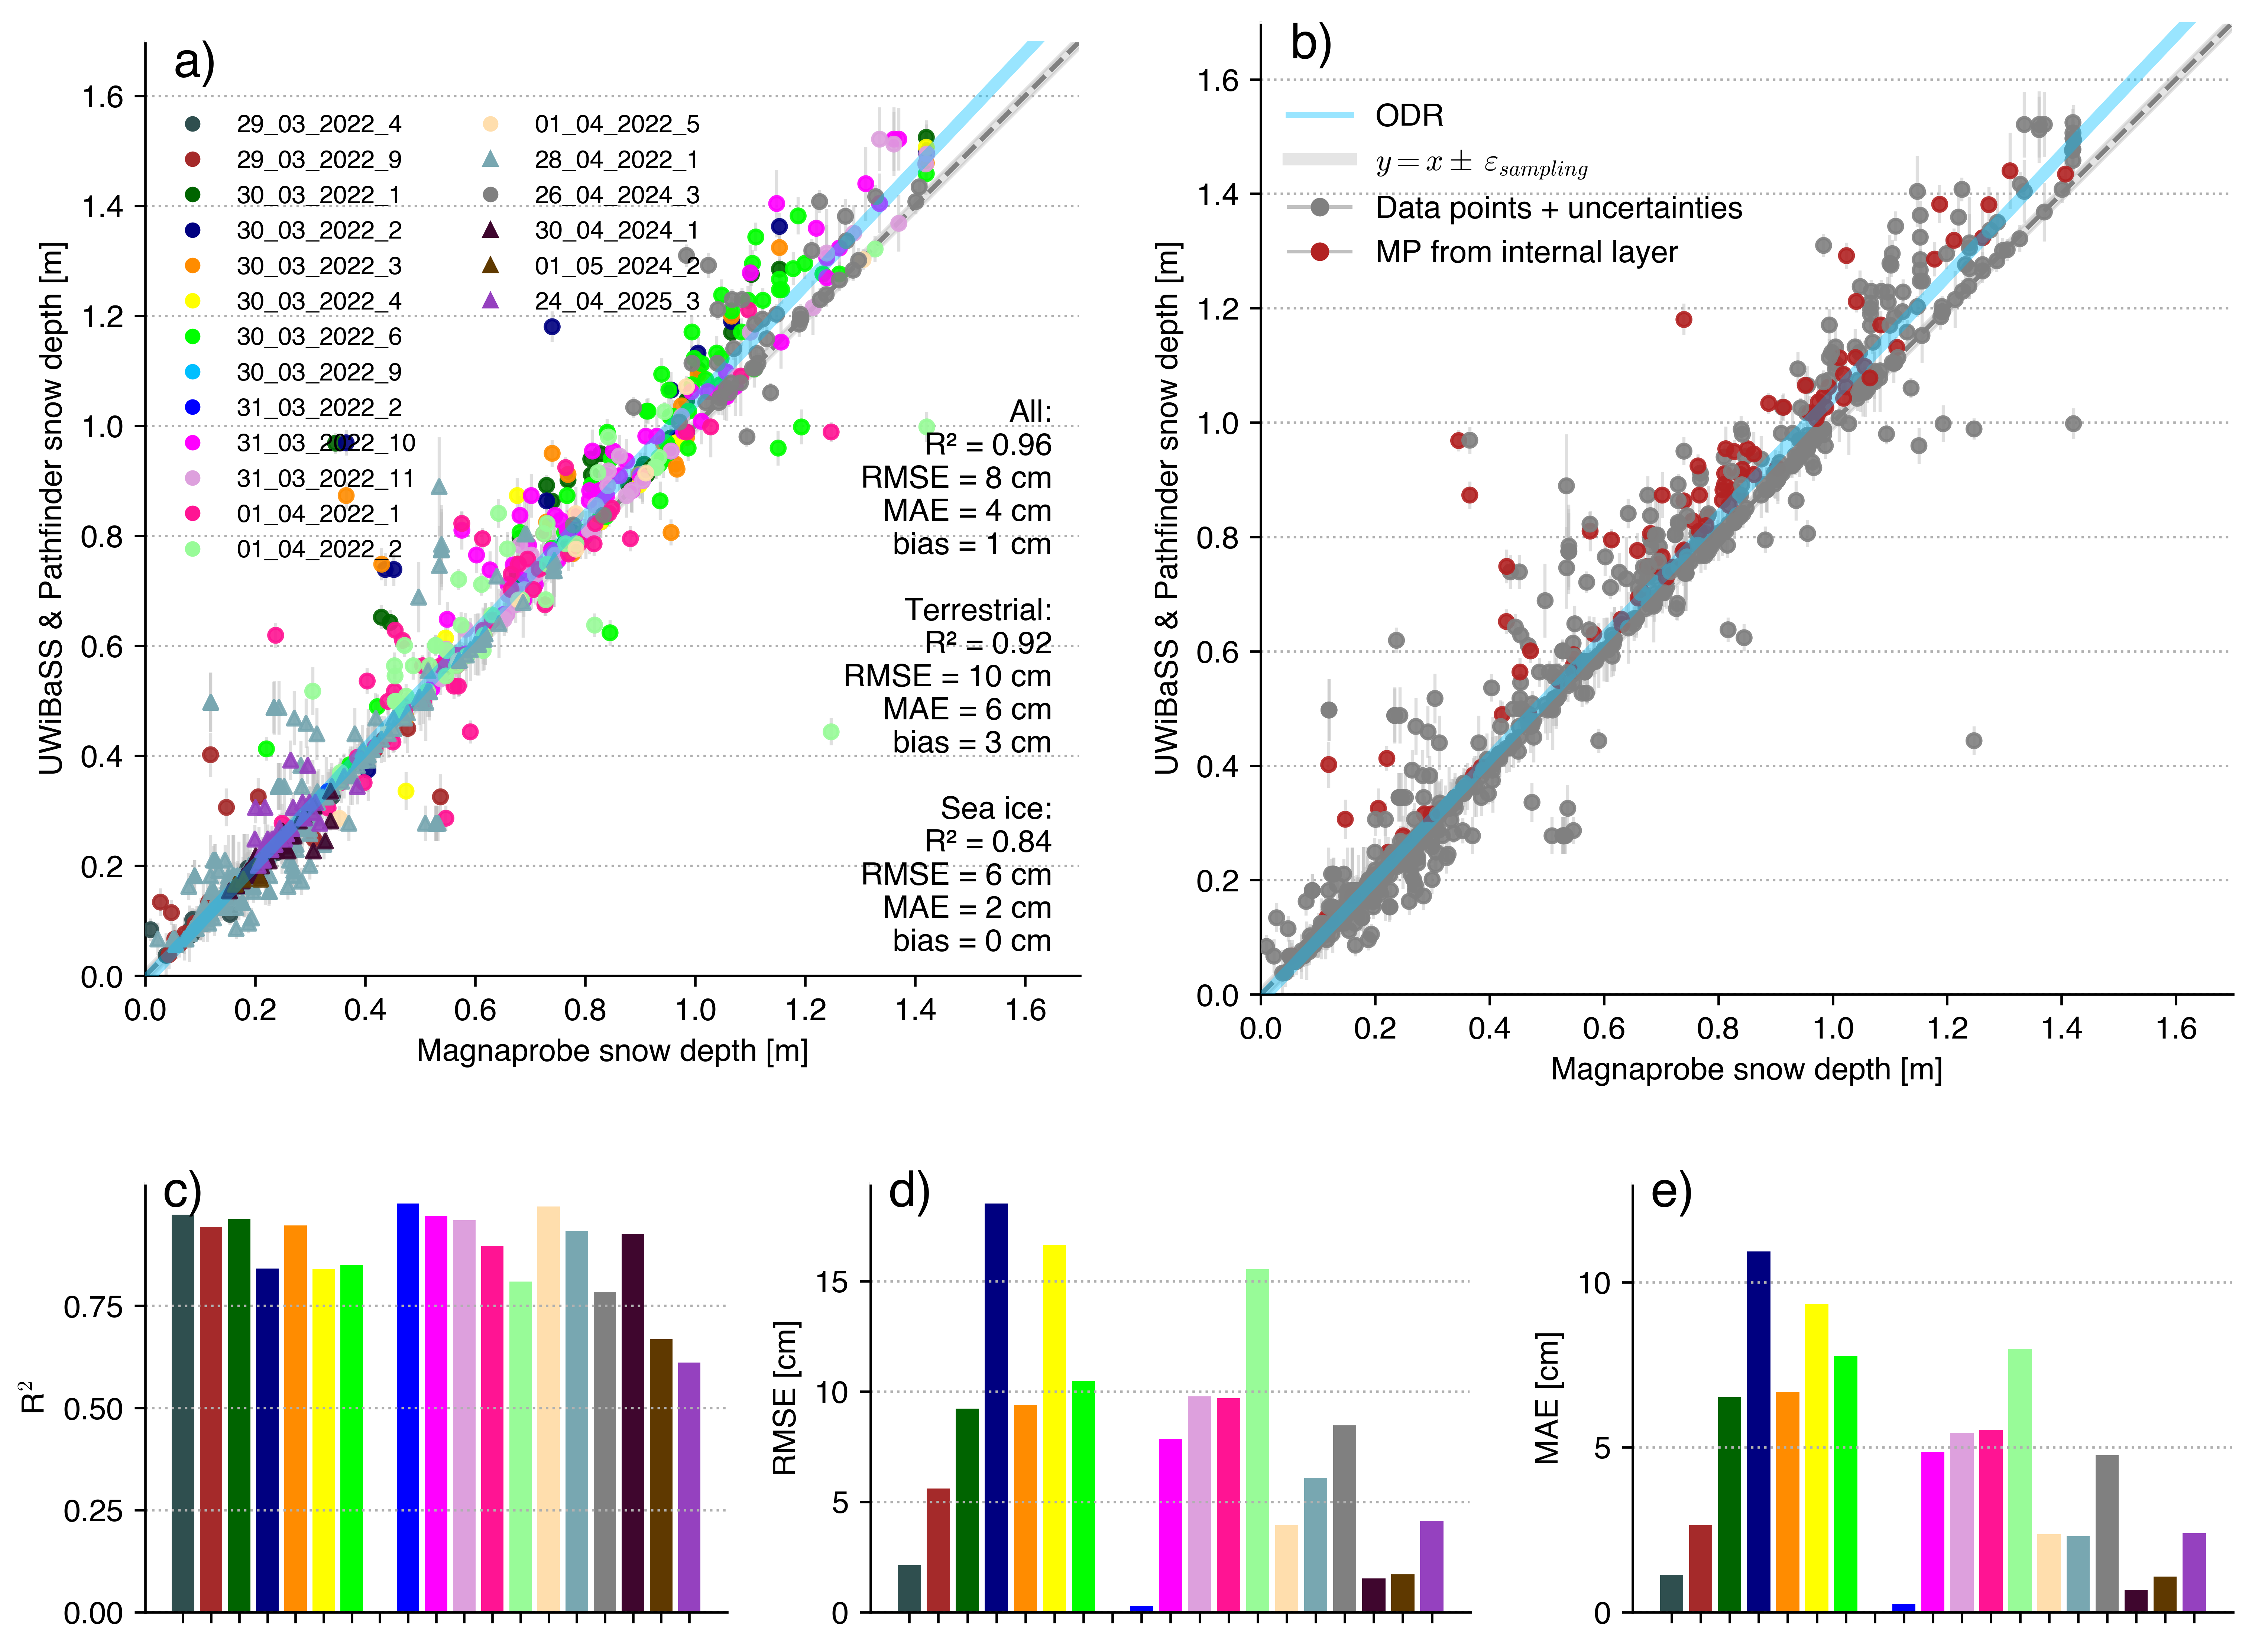

In [86]:
fig = plt.figure(figsize=(10, 8), constrained_layout=True, dpi=600)

gs = gridspec.GridSpec(2, 6, height_ratios=[3, 1], figure=fig)

ax_top_left  = fig.add_subplot(gs[0, 0:3])   
ax_top_right = fig.add_subplot(gs[0, 3:6])  

ax_bottom_1 = fig.add_subplot(gs[1, 0:2])
ax_bottom_2 = fig.add_subplot(gs[1, 2:4])
ax_bottom_3 = fig.add_subplot(gs[1, 4:6])

ax_top_left.set_aspect('equal', adjustable='box')
ax_top_right.set_aspect('equal', adjustable='box')
import string
axes = [ax_top_left, ax_top_right, ax_bottom_1, ax_bottom_2, ax_bottom_3]
for idx, a in enumerate(axes):
    a.grid(ls=':', axis='y')
    a.spines['top'].set_color('white')
    a.spines['right'].set_color('white')

ax_top_left.text(0.03, 1, f'a)', transform=ax_top_left.transAxes,
        fontsize=16, fontweight='bold', va='top', ha='left')
ax_top_right.text(0.03, 1, f'b)', transform=ax_top_right.transAxes,
        fontsize=16, fontweight='bold', va='top', ha='left')
ax_bottom_1.text(0.03, 1.03, f'c)', transform=ax_bottom_1.transAxes,
        fontsize=16, fontweight='bold', va='top', ha='left')
ax_bottom_2.text(0.03, 1.03, f'd)', transform=ax_bottom_2.transAxes,
        fontsize=16, fontweight='bold', va='top', ha='left')
ax_bottom_3.text(0.03, 1.03, f'e)', transform=ax_bottom_3.transAxes,
        fontsize=16, fontweight='bold', va='top', ha='left')

ax_top_left.set_xlabel('Magnaprobe snow depth [m]')
ax_top_left.set_ylabel('UWiBaSS & Pathfinder snow depth [m]')

ax_top_right.set_xlabel('Magnaprobe snow depth [m]')
ax_top_right.set_ylabel('UWiBaSS & Pathfinder snow depth [m]')

ax_bottom_1.set_ylabel('R$^\\text{2}$')
ax_bottom_2.set_ylabel('RMSE [cm]')
ax_bottom_3.set_ylabel('MAE [cm]')

ax_bottom_1.set_yticks([0,0.25,0.5, 0.75])
ax_bottom_3.set_yticks([0, 5, 10])
ax_bottom_3.set_ylim(0, 13)
ax_bottom_1.set_xticklabels([])
ax_bottom_2.set_xticklabels([])
ax_bottom_3.set_xticklabels([])



mask = ~np.isnan(xvars) & ~np.isnan(yvars) & maskiss.astype(bool) & (yerrs < 0.1)
mask2 = ~np.isnan(xvars) & ~np.isnan(yvars)  & (yerrs < 0.1)

ax_top_right.errorbar(xvars[mask2], yvars[mask2], yerr=yerrs[mask2], color='silver', alpha=.5, fmt='none', ls='', lw=1)
ax_top_right.scatter(xvars[mask2], yvars[mask2], s=20, color=colorsis[mask2], alpha=.9, zorder=1000)


ax_top_left.errorbar(xvars[mask2], yvars[mask2], yerr=yerrs[mask2], color='silver', alpha=.5, fmt='none', ls='', lw=1)
scatter = mscatter(xvars[mask2], yvars[mask2], m=markersis[mask2], s=20, color=colorsi2s[mask2], alpha=.9, zorder=1000, ax=ax_top_left)
# scatter = mscatter(x, y, c=c, s=s, m=m, ax=ax)

ax_top_right.set_xlim(0, 1.7)
ax_top_right.set_ylim(0, 1.7)
ax_top_left.set_xlim(0, 1.7)
ax_top_left.set_ylim(0, 1.7)

# ODR FIT:
from scipy import odr
# --- define a linear function for ODR ---
def f_lin(B, x):
    return B[0] * x + B[1]  # B[0]=slope, B[1]=intercept

data = odr.RealData(xvars[mask], yvars[mask]) #, sy=yerr[mask]
model = odr.Model(f_lin)
odr_obj = odr.ODR(data, model, beta0=[1.0, 0.0])
out = odr_obj.run()

slope, intercept = out.beta

# compute fitted line & stats
xp = np.array([0, 1.7])
yp = intercept + slope * xp

ax_top_right.fill_between(xp, xp - RADAR.PF_sampling_uncertainty, xp + RADAR.PF_sampling_uncertainty, color='grey', label='Sampling precision', alpha=.2, zorder=0)
ax_top_right.plot(xp, xp, color='grey', linestyle='--', label='1:1 line')
ax_top_right.plot(xp, yp, color='deepskyblue', label='ODR', linewidth=4, zorder=1e6, alpha=.4)

ax_top_left.fill_between(xp, xp - RADAR.PF_sampling_uncertainty, xp + RADAR.PF_sampling_uncertainty, color='grey', label='Sampling precision', alpha=.2, zorder=0)
ax_top_left.plot(xp, xp, color='grey', linestyle='--', label='1:1 line')
ax_top_left.plot(xp, yp, color='deepskyblue', label='ODR', linewidth=4, zorder=1e6, alpha=.4)


# STATISTICS TEXT 

#ALL: 
# R² from ODR predictions
y_pred = intercept + slope * xvars[mask]
ss_res = np.sum((yvars[mask] - y_pred)**2)
ss_tot = np.sum((yvars[mask] - np.mean(yvars[mask]))**2)
r2_odr = 1 - ss_res / ss_tot

# RMSE between x and y (as you had it)
RMSE = np.sqrt(np.mean((xvars[mask] - yvars[mask])**2))
MAE = np.mean(np.abs(xvars[mask] - yvars[mask]))
bias = np.mean(yvars[mask] - xvars[mask])


#TERRESTRIAL: 
# R² from ODR predictions
mask_land = mask & (sea_ice_maskiss == False)
y_pred = intercept + slope * xvars[mask_land]
ss_res = np.sum((yvars[mask_land] - y_pred)**2)
ss_tot = np.sum((yvars[mask_land] - np.mean(yvars[mask_land]))**2)
r2_odr_terrestrial = 1 - ss_res / ss_tot

# RMSE between x and y (as you had it)
RMSE_terrestrial = np.sqrt(np.mean((xvars[mask_land] - yvars[mask_land])**2))
MAE_terrestrial = np.mean(np.abs(xvars[mask_land] - yvars[mask_land]))
bias_terrestrial = np.mean(yvars[mask_land] - xvars[mask_land])

#SEA ICE: 
# R² from ODR predictions
mask_seaice = mask & (sea_ice_maskiss == True)
y_pred = intercept + slope * xvars[mask_seaice]
ss_res = np.sum((yvars[mask_seaice] - y_pred)**2)
ss_tot = np.sum((yvars[mask_seaice] - np.mean(yvars[mask_seaice]))**2)
r2_odr_seaice = 1 - ss_res / ss_tot

# RMSE between x and y (as you had it)
RMSE_seaice = np.sqrt(np.mean((xvars[mask_seaice] - yvars[mask_seaice])**2))
MAE_seaice = np.mean(np.abs(xvars[mask_seaice] - yvars[mask_seaice]))
bias_seaice = np.mean(yvars[mask_seaice] - xvars[mask_seaice])


ax_top_left.text(
    0.97, 0.02,
    f"All:"
    f"\nR² = {r2_odr:.2f}"
    f"\nRMSE = {RMSE*100:.0f} cm"
    f"\nMAE = {MAE*100:.0f} cm"
    f"\nbias = {bias*100:.0f} cm\n"
    f"\nTerrestrial:"
    f"\nR² = {r2_odr_terrestrial:.2f}"
    f"\nRMSE = {RMSE_terrestrial*100:.0f} cm"
    f"\nMAE = {MAE_terrestrial*100:.0f} cm"
    f"\nbias = {bias_terrestrial*100:.0f} cm\n"
    f"\nSea ice:"
    f"\nR² = {r2_odr_seaice:.2f}"
    f"\nRMSE = {RMSE_seaice*100:.0f} cm"
    f"\nMAE = {MAE_seaice*100:.0f} cm"
    f"\nbias = {bias_seaice*100:.0f} cm" ,
    transform=ax_top_left.transAxes,
    va='bottom', ha='right',
    size=10,
    zorder=1e10
)


custom_legend_elements = []
for i, (target, dataset) in enumerate(zip(targets, sets)):
    custom_legend_elements.append(Line2D([0], [0], color=colors_list[i], lw=0, marker='o' if target == 'land' else '^', markersize=4, label=f'{dataset}'))
    
custom_legend_elements.append(Line2D([0], [0], color='none',  linestyle='none'))
custom_legend_elements.append(Line2D([0], [0], color='none',  linestyle='none'))
custom_legend_elements.append(Line2D([0], [0], color='none',  linestyle='none'))
custom_legend_elements.append(Line2D([0], [0], color='none',  linestyle='none'))
custom_legend_elements.append(Line2D([0], [0], color='none',  linestyle='none'))
custom_legend_elements.append(Line2D([0], [0], color='none',  linestyle='none'))

leg= ax_top_left.legend(handles=custom_legend_elements, loc='upper left', fontsize=8, frameon=False,
            bbox_to_anchor=(0, 0.945), ncol=2
            )
leg.set_zorder(1e10)


custom_legend_elements = [
    Line2D([0], [0], color='deepskyblue', lw=2, alpha=.4, label='ODR'),
    Line2D([0], [0], color='grey', lw=4, alpha=.2, label='$y=x \pm \: \\varepsilon_{sampling}$'),
    # Line2D([0], [0], color='none',  linestyle='none'),
    Line2D([0], [0], lw=1.2, color='silver', markerfacecolor='grey', markeredgecolor='none', marker='o', markersize=6, label='Data points + uncertainties'),
    Line2D([0], [0], lw=1.2, color='silver', markerfacecolor='firebrick', markeredgecolor='none', marker='o', markersize=6, label='MP from internal layer'),
]
leg= ax_top_right.legend(handles=custom_legend_elements, loc='upper left', fontsize=10, frameon=False,
            bbox_to_anchor=(0, 0.945), ncol=1
            )
leg.set_zorder(1e10)

ax_bottom_1.bar(sets, R2s, color=colors_list, label='R²')
ax_bottom_2.bar(sets, np.multiply(RMSEs, 100), color=colors_list, label='RMSE')
ax_bottom_3.bar(sets, np.multiply(MAEs, 100), color=colors_list, label='MAE')


In [92]:
fig.savefig('./export/fig06.pdf', dpi=600)


In [88]:
os.getcwd()

'/Users/torka/NORCE_T/Radar-Pathfinder/Figures_paper'